<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Build a Minimal RAG Pipeline**

Estimated time needed: **35** minutes


## Overview

This lab sits in **Module 5, Lesson 1** of the course, where the focus shifts from general LLM concepts to **Retrieval-Augmented Generation (RAG)** as a production-ready pattern for data engineering systems. In enterprise settings, RAG is used to power support assistants, policy lookup tools, and internal knowledge copilots that must remain explainable and grounded in authoritative data.

From a data engineering perspective, this workflow mirrors common platform responsibilities: preparing source data, transforming it into retrieval-friendly representations, indexing for low-latency search, and validating response quality with measurable checks.

In this hands-on lab, you will build a minimal RAG pipeline end-to-end using a structured dataset transformed into text, then test whether generated answers are grounded in retrieved evidence.


## Table of Contents
<p id="table-of-contents"></p>
<div class="alert alert-block alert-info" style="margin-top: 20px">
    <ol>
        <li><a href="#Overview">Overview</a></li>
        <li><a href="#Materials-and-Methods">Materials and Methods</a></li>
        <li><a href="#Dataset-Requirements">Dataset Requirements</a></li>
        <li><a href="#Objectives">Objectives</a></li>
        <li><a href="#Setup,-Installations,-and-Data-Checks">Setup, Installations, and Data Checks</a></li>
        <li><a href="#Corpus-Construction-from-Structured-Data">Corpus Construction from Structured Data</a></li>
        <li><a href="#Chunking-Strategy">Chunking Strategy</a></li>
        <li><a href="#Embedding-Index">Embedding Index</a></li>
        <li><a href="#Retrieval-Step">Retrieval Step</a></li>
        <li><a href="#Grounded-Generation">Grounded Generation</a></li>
        <li><a href="#Grounding-Validation">Grounding Validation</a></li>
        <li><a href="#Student-Tasks">Student Tasks</a></li>
        <li><a href="#Conclusion">Conclusion</a></li>
        <li><a href="#Author">Author</a></li>
    </ol>
</div>


## Materials and Methods

This lab uses a compact but realistic RAG pipeline composed of four stages: corpus construction, chunking, embedding, and retrieval-driven answer assembly.

Core components:
- **Corpus transformation** with [pandas](https://pandas.pydata.org/docs/) to convert structured records into retrieval-ready text.
- **Embedding model** via [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html), which creates sparse vector representations of chunk text.
- **Retriever** using [cosine similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html) to rank chunks against user prompts.
- **Grounding validator** implemented as a simple threshold-based quality classifier over lexical evidence overlap.

**Architectural Trade-offs**:
- **Speed vs. accuracy**: TF-IDF is fast and lightweight, but less semantically expressive than transformer embeddings.
- **Latency vs. memory constraints**: sparse vectors reduce memory pressure and are computationally efficient, but may miss deeper semantic matches.
- **Explainability vs. fluency**: template-grounded response assembly is transparent and auditable, but less natural than a full generative LLM response.


## Dataset Requirements

For fast execution and reproducibility, this lab uses the built-in **Breast Cancer Wisconsin Diagnostic** dataset from **`sklearn.datasets.load_breast_cancer`**.

Dataset source: [load_breast_cancer official documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).

This dataset is provided through the scikit-learn project under the <a href="https://opensource.org/licenses/BSD-3-Clause" target="_blank">BSD 3-Clause</a> license and is safe for commercial use.


## Objectives

After completing this lab, you will be able to:

- Implement a basic RAG flow using chunking, embeddings, and retrieval.
- Validate answer grounding against sample prompts.
- Explain retrieval quality using practical data engineering metrics and evidence traces.


## Setup, Installations, and Data Checks

We begin by installing dependencies, importing libraries, and running basic data quality checks. In production data platforms, these checks are not optional: schema validation, null profiling, and duplicate checks are part of CI/CD quality gates and governance policies.

Run the installation cell first.


In [1]:
# Install all required libraries quietly to keep notebook output clean.
%pip install -q pandas numpy scikit-learn matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


The environment is now prepared. Next, we import the core libraries and set deterministic behavior for repeatable results. Determinism is a practical requirement when teams need reproducible debugging and model validation across environments.

Reference: [NumPy random seeding](https://numpy.org/doc/stable/reference/random/generated/numpy.random.seed.html).


In [2]:
# Import numerical and tabular processing libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import dataset and retrieval components from scikit-learn.
from sklearn.datasets import load_breast_cancer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Set a global seed for reproducible behavior.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment initialized and imports loaded.")

Environment initialized and imports loaded.


Now we ingest the dataset and expose both features and labels in a DataFrame. This is the source data contract for the downstream RAG pipeline.

We keep a human-readable `diagnosis` field so retrieval outputs can be interpreted quickly by analysts and auditors.


In [3]:
# Load the dataset as a pandas frame for easy feature operations.
dataset = load_breast_cancer(as_frame=True)
df = dataset.frame.copy()

# Map numeric target labels to text values for interpretability.
target_map = dict(enumerate(dataset.target_names))
df["diagnosis"] = df["target"].map(target_map)

# Inspect the incoming data shape and a small preview.
print("Dataset shape:", df.shape)
df.head(3)

Dataset shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant


The dataset loads with a consistent schema, which is a good baseline. Next, we formalize data quality checks that mirror enterprise guardrails.

These checks are lightweight but high impact: they detect common ingestion failures before expensive indexing and retrieval stages begin.


In [ ]:
# Build a compact schema and null profile for governance checks.
dq_summary = pd.DataFrame(
    {
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "null_count": df.isnull().sum().values,
    }
)

# Count duplicate rows as an integrity signal.
duplicate_count = int(df.duplicated().sum())

# Print key checks and show a schema snapshot.
print("Duplicate rows:", duplicate_count)
print("Columns with nulls:", int((dq_summary["null_count"] > 0).sum()))
dq_summary.head(10)

Duplicate rows: 0
Columns with nulls: 0


,column,dtype,null_count
0,mean radius,float64,0
1,mean texture,float64,0
2,mean perimeter,float64,0
3,mean area,float64,0
4,mean smoothness,float64,0
5,mean compactness,float64,0
6,mean concavity,float64,0
7,mean concave points,float64,0
8,mean symmetry,float64,0
9,mean fractal dimension,float64,0


## Corpus Construction from Structured Data

RAG starts with textual evidence. Because our source is tabular, we convert each row into a compact narrative record. This is a practical pattern when operational data originates in relational tables but retrieval operates over text chunks.

The first cell defines the transformation function, and the next cell applies it across all rows.


In [ ]:
# Select a compact set of descriptive features for each text record.
selected_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
]


def row_to_document(row):
    # Convert numeric columns into readable feature statements.
    feature_parts = [f"{feat}: {row[feat]:.3f}" for feat in selected_features]
    # Attach diagnosis label to support grounded retrieval later.
    return f"Case {int(row.name)} | diagnosis: {row['diagnosis']} | " + " | ".join(
        feature_parts
    )

Applying the function at scale yields the base document corpus for indexing. Review the sample output to confirm that each record contains both a label and feature context.


In [6]:
# Materialize one document per source row.
documents = df.apply(row_to_document, axis=1).tolist()

# Verify corpus scale and inspect a sample record.
print("Number of source documents:", len(documents))
print("Sample document:")
print(documents[0])

Number of source documents: 569
Sample document:
Case 0 | diagnosis: malignant | mean radius: 17.990 | mean texture: 10.380 | mean perimeter: 122.800 | mean area: 1001.000 | mean smoothness: 0.118


## Chunking Strategy

Chunking controls how much context each retrieval unit contains. Smaller chunks improve precision but can lose context; larger chunks improve context but may dilute relevance. We implement overlapping fixed-length chunks to balance this trade-off.

This design aligns with the module focus on chunk granularity and context assembly.


In [ ]:
def chunk_text(text, chunk_size=85, overlap=20):
    # Prevent invalid settings that could cause infinite loops.
    if chunk_size <= overlap:
        raise ValueError("chunk_size must be greater than overlap.")

    # Slide a fixed window with overlap to preserve local continuity.
    step = chunk_size - overlap
    return [text[i : i + chunk_size] for i in range(0, len(text), step)]

Next, we apply chunking to every document and retain provenance (`doc_id`, `chunk_id`). Provenance is critical for auditability and answer grounding checks.


In [8]:
# Create a table of chunks with source pointers for traceability.
chunk_records = []

for doc_id, doc in enumerate(documents):
    # Split each document into overlapping text chunks.
    doc_chunks = chunk_text(doc, chunk_size=85, overlap=20)
    # Store each chunk with document and local chunk identifiers.
    for chunk_id, chunk in enumerate(doc_chunks):
        chunk_records.append({"doc_id": doc_id, "chunk_id": chunk_id, "text": chunk})

chunk_df = pd.DataFrame(chunk_records)
print("Total chunks:", len(chunk_df))
chunk_df.head(5)

Total chunks: 1707


,doc_id,chunk_id,text
0,0,0,Case 0 | diagnosis: malignant | mean radius: 1...
1,0,1,e: 10.380 | mean perimeter: 122.800 | mean are...
2,0,2,smoothness: 0.118
3,1,0,Case 1 | diagnosis: malignant | mean radius: 2...
4,1,1,e: 17.770 | mean perimeter: 132.900 | mean are...


## Embedding Index

Now we embed chunks into vector space. For a minimal, dependency-light notebook, we use TF-IDF embeddings. In production, this stage could be swapped with transformer embeddings while preserving the same retrieval interface.

Official API: [TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).


In [9]:
# Fit a TF-IDF encoder over all chunk texts.
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words="english")
chunk_matrix = vectorizer.fit_transform(chunk_df["text"])

# Report matrix geometry to confirm index construction.
print("Chunk matrix shape:", chunk_matrix.shape)
print("Vocabulary size:", len(vectorizer.vocabulary_))

Chunk matrix shape: (1707, 4836)
Vocabulary size: 4836


## Retrieval Step

Retrieval transforms a natural-language prompt into vector space and ranks chunks by semantic closeness. This is the key bridge from user intent to evidence selection.

Official API: [cosine_similarity](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html).


In [ ]:
def retrieve_chunks(query, top_k=3):
    # Encode the query using the same fitted vectorizer.
    query_vec = vectorizer.transform([query])
    # Compute similarity scores against all stored chunks.
    scores = cosine_similarity(query_vec, chunk_matrix).ravel()

    # Select top-k chunks and keep ranking scores.
    top_idx = np.argsort(scores)[::-1][:top_k]
    results = chunk_df.iloc[top_idx].copy()
    results["score"] = scores[top_idx]
    return results.sort_values("score", ascending=False).reset_index(drop=True)


demo_query = "Find malignant cases with larger mean area and perimeter."
retrieve_chunks(demo_query, top_k=3)

,doc_id,chunk_id,text,score
0,406,1,: 14.860 | mean perimeter: 104.300 | mean area...,0.166195
1,319,1,: 17.000 | mean perimeter: 78.600 | mean area:...,0.165014
2,45,1,re: 17.600 | mean perimeter: 123.700 | mean ar...,0.164808


The retriever returns ranked evidence chunks with traceable scores. Next, we assemble a minimal grounded response that explicitly cites retrieved content instead of inventing unsupported claims.


## Grounded Generation

In a full RAG system, an LLM would synthesize the final answer from retrieved context. To keep this lab lightweight and reproducible, we use a deterministic template-based generator that references top evidence directly.

This design keeps the focus on pipeline mechanics and grounding evaluation rather than model hosting complexity.


In [ ]:
def generate_grounded_answer(query, top_k=3):
    # Retrieve evidence chunks for the incoming query.
    evidence = retrieve_chunks(query, top_k=top_k)
    # Concatenate evidence text for later grounding checks.
    evidence_text = " || ".join(evidence["text"].tolist())

    # Build a deterministic, evidence-first response.
    primary = (
        evidence.iloc[0]["text"] if len(evidence) > 0 else "No evidence retrieved."
    )
    secondary = (
        evidence.iloc[1]["text"] if len(evidence) > 1 else "No secondary evidence."
    )
    answer = f"Answer draft: {primary} | Supporting detail: {secondary}"
    return answer, evidence_text, evidence

Now we run sample prompts and capture outputs in a structured log. This log becomes the basis for the grounding validation step and supports repeatable quality reporting.


In [ ]:
# Define representative prompts for retrieval-grounding checks.
sample_prompts = [
    "Find evidence of malignant diagnosis linked to larger mean area.",
    "Find evidence of benign diagnosis with smoother measurements.",
    "Which records mention higher mean texture and malignant label?",
]

# Execute the minimal RAG flow for each prompt.
run_log = []
for prompt in sample_prompts:
    answer, evidence_text, evidence = generate_grounded_answer(prompt, top_k=3)
    run_log.append({"prompt": prompt, "answer": answer, "evidence_text": evidence_text})

results_df = pd.DataFrame(run_log)
results_df[["prompt", "answer"]]

,prompt,answer
0,Find evidence of malignant diagnosis linked to...,Answer draft: Case 8 | diagnosis: malignant | ...
1,Find evidence of benign diagnosis with smoothe...,Answer draft: Case 150 | diagnosis: benign | m...
2,Which records mention higher mean texture and ...,Answer draft: Case 8 | diagnosis: malignant | ...


## Grounding Validation

Grounding means the answer should be supported by retrieved evidence. We implement a transparent lexical-overlap validator as a practical baseline metric.

In enterprise pipelines, this can be extended with citation checks, semantic entailment models, or human review loops.


In [ ]:
def grounding_score(answer, evidence_text):
    # Normalize text to lowercase alphanumeric tokens.
    clean_answer = "".join(ch.lower() if ch.isalnum() else " " for ch in answer)
    clean_evidence = "".join(
        ch.lower() if ch.isalnum() else " " for ch in evidence_text
    )

    # Keep medium-length tokens to reduce trivial matches.
    answer_tokens = [t for t in clean_answer.split() if len(t) > 3]
    evidence_tokens = set(clean_evidence.split())

    # Compute overlap ratio as a simple grounding proxy.
    if not answer_tokens:
        return 0.0
    overlap = [t for t in answer_tokens if t in evidence_tokens]
    return len(overlap) / len(answer_tokens)

With the validator defined, we now score each prompt-response pair and apply a quality threshold. This gives a compact pass/fail signal useful for regression monitoring in CI pipelines.


In [14]:
# Score each answer against its retrieved evidence text.
results_df["grounding_score"] = results_df.apply(
    lambda r: grounding_score(r["answer"], r["evidence_text"]), axis=1
)

# Apply a baseline quality threshold for grounded outputs.
results_df["grounded_flag"] = results_df["grounding_score"] >= 0.55

results_df[["prompt", "grounding_score", "grounded_flag"]]

,prompt,grounding_score,grounded_flag
0,Find evidence of malignant diagnosis linked to...,0.800000,True
1,Find evidence of benign diagnosis with smoothe...,0.818182,True
2,Which records mention higher mean texture and ...,0.800000,True


A visual summary helps teams quickly detect weak prompts or unstable retrieval behavior. In production, this chart can be tracked over builds to detect regressions.


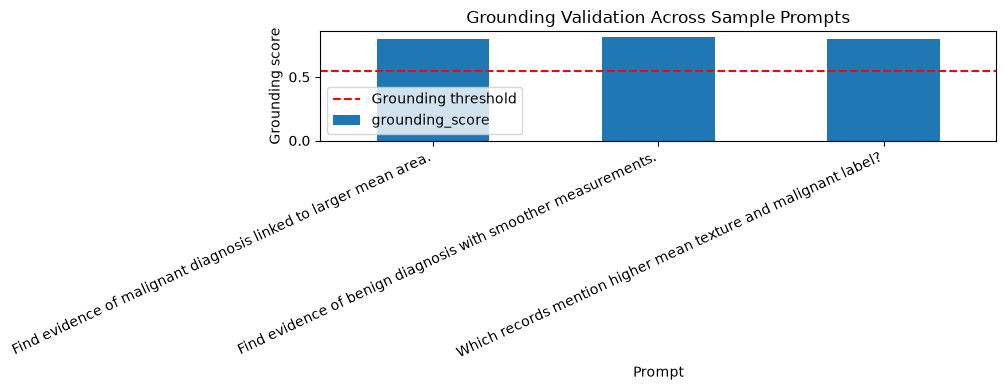

In [ ]:
# Plot grounding scores to compare prompt-level quality.
ax = results_df.plot(
    x="prompt",
    y="grounding_score",
    kind="bar",
    legend=False,
    color="#1f77b4",
    figsize=(10, 4),
)

# Draw threshold reference to separate pass/fail regions.
ax.axhline(0.55, color="red", linestyle="--", label="Grounding threshold")
ax.set_ylabel("Grounding score")
ax.set_xlabel("Prompt")
ax.set_title("Grounding Validation Across Sample Prompts")
ax.legend()
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

The chart provides an immediate quality snapshot: prompts below threshold need better chunking configuration, richer features, or improved embedding strategy. This is exactly the diagnostic mindset required for RAG operations in enterprise environments.

## Student Tasks


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question #1: </h1>
<b>Create one new prompt focused on benign cases, retrieve the top 4 evidence chunks, generate a grounded answer, and compute its grounding score.</b>
</div>


In [ ]:
# TODO: Write a new prompt about benign patterns.
# TODO: Retrieve top 4 chunks with retrieve_chunks().
# TODO: Generate a grounded answer with generate_grounded_answer().
# TODO: Compute and print grounding_score(answer, evidence_text).

# Define a new student prompt focused on benign diagnosis evidence.
student_prompt = (
    "Show benign cases with relatively smooth measurements and moderate area values."
)

# Retrieve top 4 relevant chunks from the vector index.
student_retrieval = retrieve_chunks(student_prompt, top_k=4)
print(student_retrieval[["doc_id", "chunk_id", "score"]])

# Generate a grounded answer and inspect the text response.
student_answer, student_evidence_text, _ = generate_grounded_answer(
    student_prompt, top_k=4
)
print(student_answer)

# Score answer grounding against retrieved evidence.
student_score = grounding_score(student_answer, student_evidence_text)
print(f"Grounding score: {student_score:.3f}")

   doc_id  chunk_id     score
0     150         0  0.090942
1     307         0  0.090907
2     477         0  0.089983
3     310         0  0.089797
Answer draft: Case 150 | diagnosis: benign | mean radius: 13.000 | mean texture: 20.780 | mean peri | Supporting detail: Case 307 | diagnosis: benign | mean radius: 9.000 | mean texture: 14.400 | mean perim
Grounding score: 0.818


<details><summary>Click here for the solution</summary>

```python
# Define a new student prompt focused on benign diagnosis evidence.
student_prompt = "Show benign cases with relatively smooth measurements and moderate area values."

# Retrieve top 4 relevant chunks from the vector index.
student_retrieval = retrieve_chunks(student_prompt, top_k=4)
print(student_retrieval[["doc_id", "chunk_id", "score"]])

# Generate a grounded answer and inspect the text response.
student_answer, student_evidence_text, _ = generate_grounded_answer(student_prompt, top_k=4)
print(student_answer)

# Score answer grounding against retrieved evidence.
student_score = grounding_score(student_answer, student_evidence_text)
print(f"Grounding score: {student_score:.3f}")
```

</details>


## Conclusion

You now have a minimal, testable RAG workflow that follows the module’s intended progression: structured data to corpus, chunking, embedding, retrieval, grounded response assembly, and prompt-level validation. This pattern can be extended with transformer embeddings, vector databases, and LLM synthesis layers while keeping the same quality-control backbone.


## Author

<a href="https://author.skills.network/instructors/dmytro_shliakhovskyi">Dmytro Shliakhovskyi</a>

## Change Log
| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| ----------------- | ------- | ---------- | ------------------ |
| 2026-04-27 | 01 | Dmytro Shliakhovskyi | Lab created |

<h3 align="center"> © IBM Corporation 2020. All rights reserved. <h3/>
